In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 496kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.70MB/s]


In [10]:
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),
            nn.Tanh(),

            nn.AvgPool2d(kernel_size=2),

            nn.Conv2d(6, 16, kernel_size=5),
            nn.Tanh(),

            nn.AvgPool2d(kernel_size=2),

            nn.Conv2d(16, 120, kernel_size=5),
            nn.Tanh()
        )

        self.classifier = nn.Sequential(
            nn.Linear(120, 84),
            nn.Tanh(),

            nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.features(x)

        x = x.view(x.size(0), -1)

        x = self.classifier(x)

        return x




model = LeNet5().to(device)

print(model)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

ans = input('learn? ')

if ans == 'y':

    losses = []

    epochs = 5

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {running_loss / len(train_loader):.4f}")

        losses.append(running_loss / len(train_loader))

    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))
    plt.plot(losses)
    plt.show()

    torch.save({
        "epoch": epochs,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }, "/content/drive/MyDrive/neural/weights/lenet5_checkpoint.pth")

else:
    checkpoint = torch.load("/content/drive/MyDrive/neural/weights/lenet5_checkpoint.pth", map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (1): Tanh()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): Tanh()
    (5): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (6): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
    (7): Tanh()
  )
  (classifier): Sequential(
    (0): Linear(in_features=120, out_features=84, bias=True)
    (1): Tanh()
    (2): Linear(in_features=84, out_features=10, bias=True)
  )
)
learn? n


In [12]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 98.22%


In [16]:
import numpy as np
import torch


def np_tanh(z):
    return np.tanh(z)

def np_tanh_backward(grad_out, activated):
    return grad_out * (1.0 - activated * activated)

def np_softmax(logits):
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exps = np.exp(shifted)
    return exps / np.sum(exps, axis=1, keepdims=True)

def np_cross_entropy_with_logits(logits, targets_int):
    probs = np_softmax(logits)
    n = logits.shape[0]
    eps = 1e-12
    loss = -np.log(probs[np.arange(n), targets_int] + eps).mean()

    grad_logits = probs.copy()
    grad_logits[np.arange(n), targets_int] -= 1.0
    grad_logits /= n
    return loss, grad_logits


class NpConv2D:
    def __init__(self, in_ch, out_ch, ksize, rng, weight_scale=0.05):
        self.ksize = ksize
        self.w = rng.normal(0.0, weight_scale, size=(out_ch, in_ch, ksize, ksize))
        self.b = np.zeros((out_ch,), dtype=np.float64)
        self.x_cache = None
        self.dw = np.zeros_like(self.w)
        self.db = np.zeros_like(self.b)

    def forward(self, x):
        self.x_cache = x
        n, _, h, w = x.shape
        f, _, k, _ = self.w.shape
        out_h = h - k + 1
        out_w = w - k + 1
        out = np.zeros((n, f, out_h, out_w), dtype=np.float64)

        for i in range(out_h):
            for j in range(out_w):
                patch = x[:, :, i:i+k, j:j+k]
                out[:, :, i, j] = np.tensordot(patch, self.w, axes=([1, 2, 3], [1, 2, 3]))

        out += self.b[None, :, None, None]
        return out

    def backward(self, grad_out):
        x = self.x_cache
        n, c, h, w = x.shape
        f, _, k, _ = self.w.shape
        out_h = h - k + 1
        out_w = w - k + 1

        self.dw.fill(0.0)
        self.db = grad_out.sum(axis=(0, 2, 3))
        dx = np.zeros_like(x)

        for i in range(out_h):
            for j in range(out_w):
                patch = x[:, :, i:i+k, j:j+k]
                self.dw += np.einsum('nf,nckl->fckl', grad_out[:, :, i, j], patch)
                dx[:, :, i:i+k, j:j+k] += np.einsum('nf,fckl->nckl', grad_out[:, :, i, j], self.w)

        return dx


class NpAvgPool2D:
    def __init__(self, ksize=2, stride=2):
        self.ksize = ksize
        self.stride = stride
        self.x_cache = None

    def forward(self, x):
        self.x_cache = x
        n, c, h, w = x.shape
        k, s = self.ksize, self.stride
        out_h = (h - k) // s + 1
        out_w = (w - k) // s + 1
        out = np.zeros((n, c, out_h, out_w), dtype=np.float64)

        for i in range(out_h):
            for j in range(out_w):
                hs, ws = i * s, j * s
                out[:, :, i, j] = x[:, :, hs:hs+k, ws:ws+k].mean(axis=(2, 3))
        return out

    def backward(self, grad_out):
        x = self.x_cache
        dx = np.zeros_like(x)
        k, s = self.ksize, self.stride
        out_h, out_w = grad_out.shape[2], grad_out.shape[3]
        scale = 1.0 / (k * k)

        for i in range(out_h):
            for j in range(out_w):
                hs, ws = i * s, j * s
                dx[:, :, hs:hs+k, ws:ws+k] += grad_out[:, :, i, j][:, :, None, None] * scale
        return dx


class NpLinear:
    def __init__(self, in_dim, out_dim, rng, weight_scale=0.05):
        self.w = rng.normal(0.0, weight_scale, size=(in_dim, out_dim))
        self.b = np.zeros((out_dim,), dtype=np.float64)
        self.x_cache = None
        self.dw = np.zeros_like(self.w)
        self.db = np.zeros_like(self.b)

    def forward(self, x):
        self.x_cache = x
        return x @ self.w + self.b

    def backward(self, grad_out):
        x = self.x_cache
        self.dw = x.T @ grad_out
        self.db = grad_out.sum(axis=0)
        return grad_out @ self.w.T


class NpLeNetManual:
    def __init__(self, seed=42):
        local_rng = np.random.default_rng(seed)
        self.c1 = NpConv2D(1, 6, 5, local_rng)
        self.p1 = NpAvgPool2D(2, 2)
        self.c2 = NpConv2D(6, 16, 5, local_rng)
        self.p2 = NpAvgPool2D(2, 2)
        self.c3 = NpConv2D(16, 120, 5, local_rng)
        self.f1 = NpLinear(120, 84, local_rng)
        self.f2 = NpLinear(84, 10, local_rng)

        self.a1 = self.a2 = self.a3 = self.a4 = None
        self.flat_shape = None

    def forward(self, x):
        z1 = self.c1.forward(x); self.a1 = np_tanh(z1)
        h1 = self.p1.forward(self.a1)
        z2 = self.c2.forward(h1); self.a2 = np_tanh(z2)
        h2 = self.p2.forward(self.a2)
        z3 = self.c3.forward(h2); self.a3 = np_tanh(z3)
        self.flat_shape = self.a3.shape
        flat = self.a3.reshape(self.a3.shape[0], -1)
        z4 = self.f1.forward(flat); self.a4 = np_tanh(z4)
        return self.f2.forward(self.a4)

    def backward(self, grad_logits):
        g = self.f2.backward(grad_logits)
        g = np_tanh_backward(g, self.a4)
        g = self.f1.backward(g).reshape(self.flat_shape)
        g = np_tanh_backward(g, self.a3)
        g = self.c3.backward(g)
        g = self.p2.backward(g)
        g = np_tanh_backward(g, self.a2)
        g = self.c2.backward(g)
        g = self.p1.backward(g)
        g = np_tanh_backward(g, self.a1)
        _ = self.c1.backward(g)

    def sgd_step(self, lr_value):
        for lyr in [self.c1, self.c2, self.c3, self.f1, self.f2]:
            lyr.w -= lr_value * lyr.dw
            lyr.b -= lr_value * lyr.db


    def save_weights(self, file_path):
        np.savez(
            file_path,
            c1_w=self.c1.w, c1_b=self.c1.b,
            c2_w=self.c2.w, c2_b=self.c2.b,
            c3_w=self.c3.w, c3_b=self.c3.b,
            f1_w=self.f1.w, f1_b=self.f1.b,
            f2_w=self.f2.w, f2_b=self.f2.b,
        )

    def load_weights(self, file_path):
        data = np.load(file_path)

        self.c1.w[...] = data["c1_w"]; self.c1.b[...] = data["c1_b"]
        self.c2.w[...] = data["c2_w"]; self.c2.b[...] = data["c2_b"]
        self.c3.w[...] = data["c3_w"]; self.c3.b[...] = data["c3_b"]
        self.f1.w[...] = data["f1_w"]; self.f1.b[...] = data["f1_b"]
        self.f2.w[...] = data["f2_w"]; self.f2.b[...] = data["f2_b"]


def torch_batch_to_numpy(batch_images_t, batch_labels_t):
    x_np_local = batch_images_t.detach().cpu().numpy().astype(np.float64)
    y_np_local = batch_labels_t.detach().cpu().numpy().astype(np.int64)
    return x_np_local, y_np_local


def evaluate_numpy_net(np_net_local, torch_loader_local):
    total_correct_local = 0
    total_count_local = 0

    for imgs_t_local, lbls_t_local in torch_loader_local:
        x_np_local, y_np_local = torch_batch_to_numpy(imgs_t_local, lbls_t_local)
        logits_local = np_net_local.forward(x_np_local)
        pred_local = np.argmax(logits_local, axis=1)

        total_correct_local += (pred_local == y_np_local).sum()
        total_count_local += y_np_local.shape[0]

    return total_correct_local / total_count_local


np_net_instance = NpLeNetManual(seed=7)
np_lr_local = 0.01
np_epoch_count_local = 3

ans = input('learn? ')
if ans == 'y':
    for ep_local in range(np_epoch_count_local):
        loss_sum_local = 0.0
        batch_count_local = 0

        for imgs_t_local, lbls_t_local in train_loader:
            x_np_local, y_np_local = torch_batch_to_numpy(imgs_t_local, lbls_t_local)

            logits_local = np_net_instance.forward(x_np_local)
            loss_local, grad_logits_local = np_cross_entropy_with_logits(logits_local, y_np_local)

            np_net_instance.backward(grad_logits_local)
            np_net_instance.sgd_step(np_lr_local)

            loss_sum_local += loss_local
            batch_count_local += 1

        train_loss_local = loss_sum_local / batch_count_local

        print(f"epoch={ep_local+1} train_loss={train_loss_local:.4f}")
    np_net_instance.save_weights("/content/drive/MyDrive/neural/weights/manual_weights.npz")
else:
    np_net_instance.load_weights("/content/drive/MyDrive/neural/weights/manual_weights.npz")

# epoch=1: 1.5268
# epoch=2: 0.5039
# epoch=3: 0.3261


learn? n


In [8]:
correct_local = 0
total_local = 0

for images_t_local, labels_t_local in test_loader:
    images_np_local = images_t_local.detach().cpu().numpy().astype(np.float64)
    labels_np_local = labels_t_local.detach().cpu().numpy().astype(np.int64)

    outputs_np_local = np_net_instance.forward(images_np_local)

    predicted_np_local = np.argmax(outputs_np_local, axis=1)

    total_local += labels_np_local.shape[0]
    correct_local += np.sum(predicted_np_local == labels_np_local)

accuracy_local = 100.0 * correct_local / total_local
print(f"Accuracy: {accuracy_local:.2f}%")

Accuracy: 91.88%


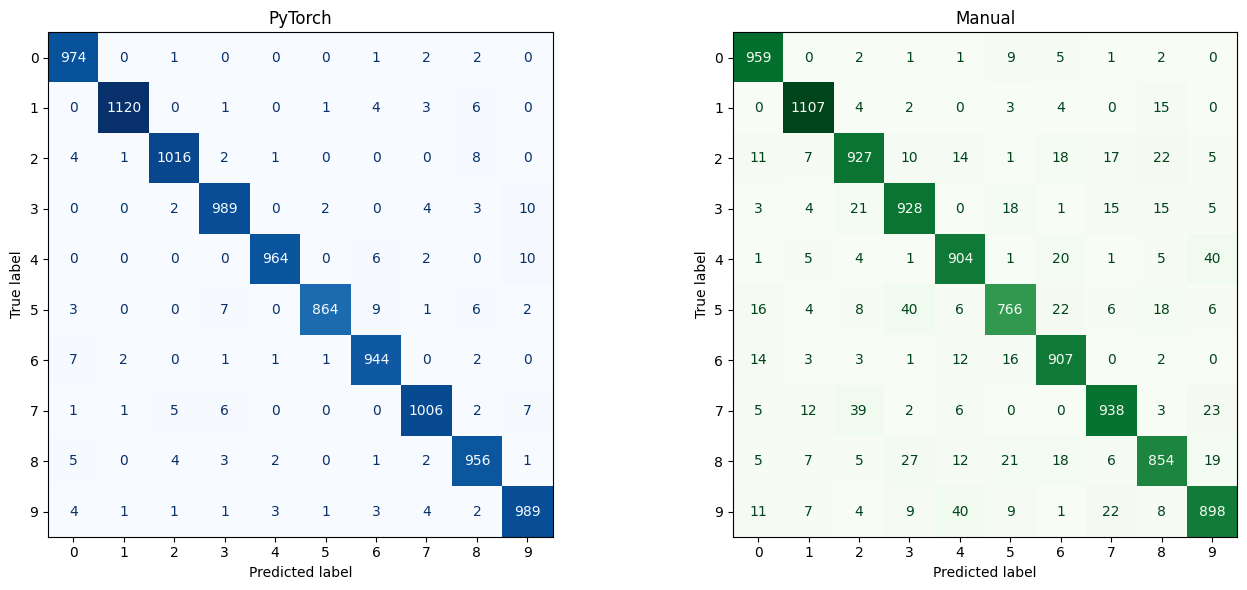

In [22]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_preds_torch(model, data_loader, device):
    model.eval()
    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            logits = model(images)
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            y_pred_all.append(preds)
            y_true_all.append(labels.numpy())

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)
    return y_true_all, y_pred_all

def torch_batch_to_numpy(batch_images_t, batch_labels_t):
    x_np_local = batch_images_t.detach().cpu().numpy().astype(np.float64)
    y_np_local = batch_labels_t.detach().cpu().numpy().astype(np.int64)
    return x_np_local, y_np_local


def get_preds_numpy(np_model, data_loader):
    y_true_all = []
    y_pred_all = []

    for images_t, labels_t in data_loader:
        x_np, y_np = torch_batch_to_numpy(images_t, labels_t)
        logits = np_model.forward(x_np)
        preds = np.argmax(logits, axis=1)

        y_pred_all.append(preds)
        y_true_all.append(y_np)

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)
    return y_true_all, y_pred_all

def plot_two_confusion_matrices(
    y_true_torch, y_pred_torch,
    y_true_np, y_pred_np,
    class_names=None,
    save_path=None
):

    labels = np.unique(y_true_torch) if class_names is None else np.arange(len(class_names))

    cm_torch = confusion_matrix(y_true_torch, y_pred_torch, labels=labels, normalize=None)
    cm_np = confusion_matrix(y_true_np, y_pred_np, labels=labels, normalize=None)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_torch, display_labels=class_names)
    disp1.plot(ax=axes[0], colorbar=False, cmap="Blues", values_format="d")
    axes[0].set_title("PyTorch")

    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_np, display_labels=class_names)
    disp2.plot(ax=axes[1], colorbar=False, cmap="Greens", values_format="d")
    axes[1].set_title("Manual")

    plt.tight_layout()

    plt.show()


class_names = [str(i) for i in range(10)]
y_true_torch, y_pred_torch = get_preds_torch(model, test_loader, device)
y_true_np, y_pred_np = get_preds_numpy(np_net_instance, test_loader)

plot_two_confusion_matrices(
    y_true_torch, y_pred_torch,
    y_true_np, y_pred_np,
    class_names=class_names
)

In [8]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from IPython.display import HTML
import numpy as np
import cv2
from PIL import Image
import io
import base64
import torch.nn.functional as F
from IPython.display import HTML

from IPython.display import HTML

canvas_html = """
<canvas id="canvas" width="280" height="280"
style="border:2px solid black;"></canvas>

<br><br>

<button onclick="clearCanvas()">Clear</button>
<button onclick="startStream()">Start</button>
<button onclick="stopStream()">Stop</button>

<h3 id="status">Stopped</h3>

<script>

const canvas = document.getElementById('canvas');
const ctx = canvas.getContext('2d');

let streaming = false;
let intervalId = null;

function reset() {
    ctx.fillStyle = 'black';
    ctx.fillRect(0, 0, canvas.width, canvas.height);
    ctx.beginPath();
}

reset();

ctx.strokeStyle = 'white';
ctx.lineWidth = 10;
ctx.lineCap = 'round';

let drawing = false;

canvas.onmousedown = (e) => {
    drawing = true;
    const r = canvas.getBoundingClientRect();
    ctx.beginPath();
    ctx.moveTo(e.clientX - r.left, e.clientY - r.top);
};

canvas.onmouseup = () => {
    drawing = false;
    ctx.beginPath();
};

canvas.onmousemove = (e) => {
    if (!drawing) return;

    const r = canvas.getBoundingClientRect();

    ctx.lineTo(e.clientX - r.left, e.clientY - r.top);
    ctx.stroke();
};

function clearCanvas() {
    reset();
}

function startStream() {

    if (streaming) return;

    streaming = true;

    document.getElementById("status").innerText = "Running...";

    intervalId = setInterval(() => {

        const dataURL = canvas.toDataURL();

        google.colab.kernel.invokeFunction(
            'notebook.stream',
            [dataURL],
            {}
        );

    }, 400);
}

function stopStream() {

    streaming = false;

    document.getElementById("status").innerText = "Stopped";

    if (intervalId) {
        clearInterval(intervalId);
        intervalId = null;
    }
}

</script>
"""

display(HTML(canvas_html))

display(Javascript('google.colab.output.setIframeHeight(400, true, {maxHeight: 500})'))

def data_url_to_image(data_url):

    header, encoded = data_url.split(",")

    data = base64.b64decode(encoded)

    image = Image.open(io.BytesIO(data))

    return image

def predict_probs(img):

    img = np.array(img)

    img = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)

    img = cv2.resize(img, (32, 32))

    img = img.astype(np.float32) / 255.0


    img = (img - 0.5) / 0.5

    tensor = torch.tensor(img).float().unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]

    return probs


from google.colab import output
import matplotlib.pyplot as plt
from IPython.display import clear_output
import ipywidgets as widgets

out = widgets.Output()
display(out)

def stream(data_url):

    img = data_url_to_image(data_url)

    probs = predict_probs(img)

    pred = int(np.argmax(probs))


    with out:

        out.clear_output(wait=True)

        print(f"Prediction: {pred}\n")

        for i, p in enumerate(probs):
            bar = "█" * int(p * 25)
            print(f"{i}: {p:.3f} {bar}")

output.register_callback("notebook.stream", stream)

<IPython.core.display.Javascript object>

Output()